# 📦 Cardboard Box Defect Detection — YOLOv8

**Dataset:** [Cardboard Box Defect — Roboflow Universe](https://universe.roboflow.com/psm-cqw6v/cardboard-box-defect-qkrrj-jzm1k)  
**Model:** YOLOv8x (extra-large, highest accuracy variant)  
**Task:** Object Detection  
**Goal:** Detect and localise defects on cardboard boxes with maximum precision.

---

## 🗂️ Notebook Structure
| # | Section |
|---|---|
| 1 | Environment setup & GPU check |
| 2 | Dataset download from Roboflow |
| 3 | Data exploration & visualisation |
| 4 | Dataset YAML review & augmentation config |
| 5 | Model training (high-accuracy settings) |
| 6 | Training curves & metrics |
| 7 | Validation / mAP evaluation |
| 8 | Inference on test images |
| 9 | Confusion matrix & PR curve |
| 10 | Model export (ONNX / TorchScript) |


## 1️⃣  Environment Setup & GPU Check

In [1]:
# ── Install required packages ──────────────────────────────────────────────
# ultralytics : official YOLOv8 framework by Ultralytics
# roboflow    : download datasets directly from Roboflow Universe
# supervision : advanced visualisation helpers (bounding boxes, annotations)
# matplotlib / seaborn : plots for EDA and training curves
#%pip install ultralytics roboflow supervision matplotlib seaborn opencv-python-headless

In [2]:
#pip install ultralytics

In [3]:
# ── Standard imports ───────────────────────────────────────────────────────
import os
import random
import shutil
import yaml
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import supervision as sv
from IPython.display import Image, display

import torch
from ultralytics import YOLO

# ── Reproducibility seed ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── GPU availability ────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n{'='*50}")
print(f"  Device        : {device.upper()}")
if device == 'cuda':
    print(f"  GPU Name      : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM (GB)     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}")
    print(f"  CUDA version  : {torch.version.cuda}")
print(f"  PyTorch       : {torch.__version__}")
print(f"{'='*50}\n")

# ⚠️ If device == 'cpu', training will be very slow.
# Consider using Google Colab (Runtime → Change runtime → T4 GPU) or Kaggle.


  Device        : CUDA
  GPU Name      : NVIDIA RTX 2000 Ada Generation
  VRAM (GB)     : 17.2
  CUDA version  : 12.8
  PyTorch       : 2.11.0+cu128



## 2️⃣  Download Dataset from Roboflow

In [4]:
# ── Roboflow dataset download ───────────────────────────────────────────────
# We download the dataset in YOLOv8 format.
# YOLOv8 format provides:
#   • images/train, images/val, images/test  — raw JPEG/PNG files
#   • labels/train, labels/val, labels/test  — .txt annotation files
#   • data.yaml                               — class names + split paths

from roboflow import Roboflow

# rf = Roboflow(api_key="RA9OLAyrt4aKPeXjVOtq")
# project  = rf.workspace("psm-cqw6v").project("cardboard-box-defect-qkrrj-jzm1k")
# version  = project.version(2)
# dataset  = version.download("yolov8")

# The dataset root directory (contains data.yaml)
DATASET_DIR = Path("Cardboard-Box-Defect-2")
DATA_YAML   = DATASET_DIR / "data.yaml"

print(f"\nDataset downloaded to : {DATASET_DIR}")
print(f"YAML config           : {DATA_YAML}")


Dataset downloaded to : Cardboard-Box-Defect-2
YAML config           : Cardboard-Box-Defect-2\data.yaml


## 3️⃣  Data Exploration & Visualisation

In [5]:
# ── Load and inspect the YAML configuration ────────────────────────────────
with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

CLASS_NAMES = config['names']          # list of class label strings
NUM_CLASSES = config['nc']             # number of classes

print("\n📋 Dataset Configuration")
print(f"  Number of classes : {NUM_CLASSES}")
print(f"  Class names       : {CLASS_NAMES}")
print(f"  Train path        : {config.get('train', 'N/A')}")
print(f"  Val path          : {config.get('val',   'N/A')}")
print(f"  Test path         : {config.get('test',  'N/A')}")


📋 Dataset Configuration
  Number of classes : 3
  Class names       : ['no defect', 'torn', 'wrinkle']
  Train path        : train\images
  Val path          : valid\images
  Test path         : test\images


In [6]:
# ── Count images in each split ─────────────────────────────────────────────
def count_files(split: str, ext: str = '*.jpg') -> int:
    """Count files with a given extension in a dataset split."""
    p = DATASET_DIR / split / 'images'
    if not p.exists():
        p = DATASET_DIR / split  # fallback flat structure
    return len(list(p.glob(ext))) + len(list(p.glob('*.png')))

splits = ['train', 'valid', 'test']
counts = {s: count_files(s) for s in splits}

print("\n📊 Image counts per split:")
for s, n in counts.items():
    print(f"  {s:10s}: {n:>5d} images")
print(f"  {'TOTAL':10s}: {sum(counts.values()):>5d} images")


📊 Image counts per split:
  train     :  2997 images
  valid     :   286 images
  test      :   141 images
  TOTAL     :  3424 images


Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.


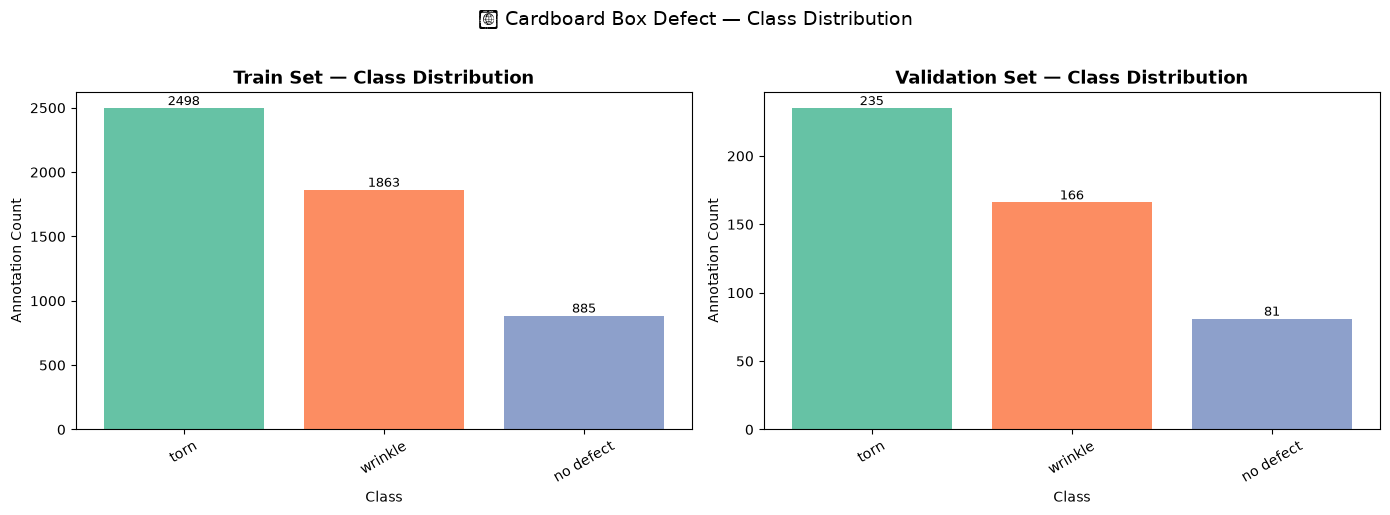

Saved → class_distribution.png


In [7]:
# ── Parse all label files → class distribution ─────────────────────────────
def get_class_distribution(split: str) -> Counter:
    """
    Read every .txt label file in a split and count class occurrences.
    YOLOv8 label format per line: <class_id> <cx> <cy> <w> <h>  (normalised)
    """
    label_dir = DATASET_DIR / split / 'labels'
    if not label_dir.exists():
        label_dir = DATASET_DIR / split
    counter = Counter()
    for lbl_file in label_dir.glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                cls_id = int(line.split()[0])
                counter[CLASS_NAMES[cls_id]] += 1
    return counter

train_dist = get_class_distribution('train')
val_dist   = get_class_distribution('valid')

# ── Bar chart: class distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (dist, title) in zip(axes, [(train_dist, 'Train'), (val_dist, 'Validation')]):
    classes = list(dist.keys())
    values  = list(dist.values())
    bars = ax.bar(classes, values, color=sns.color_palette('Set2', len(classes)))
    ax.bar_label(bars, fmt='%d', fontsize=9)
    ax.set_title(f'{title} Set — Class Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Annotation Count')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('📦 Cardboard Box Defect — Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → class_distribution.png")

In [8]:
def load_image_and_labels(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
    boxes = []

    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = list(map(float, line.split()))
                boxes.append(parts)

    return img, boxes, h, w

In [9]:
def draw_boxes(ax, img, boxes, h, w):
    ax.imshow(img)

    for box in boxes:
        cls, x, y, bw, bh = box

        # YOLO → pixel conversion
        x1 = (x - bw / 2) * w
        y1 = (y - bh / 2) * h
        x2 = (x + bw / 2) * w
        y2 = (y + bh / 2) * h

        ax.add_patch(plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor='red',
            linewidth=2
        ))

In [10]:
train_imgs = list((DATASET_DIR / 'train' / 'images').glob('*.jpg')) + \
             list((DATASET_DIR / 'train' / 'images').glob('*.png'))

samples = random.sample(train_imgs, min(8, len(train_imgs)))

ValueError: too many values to unpack (expected 5)

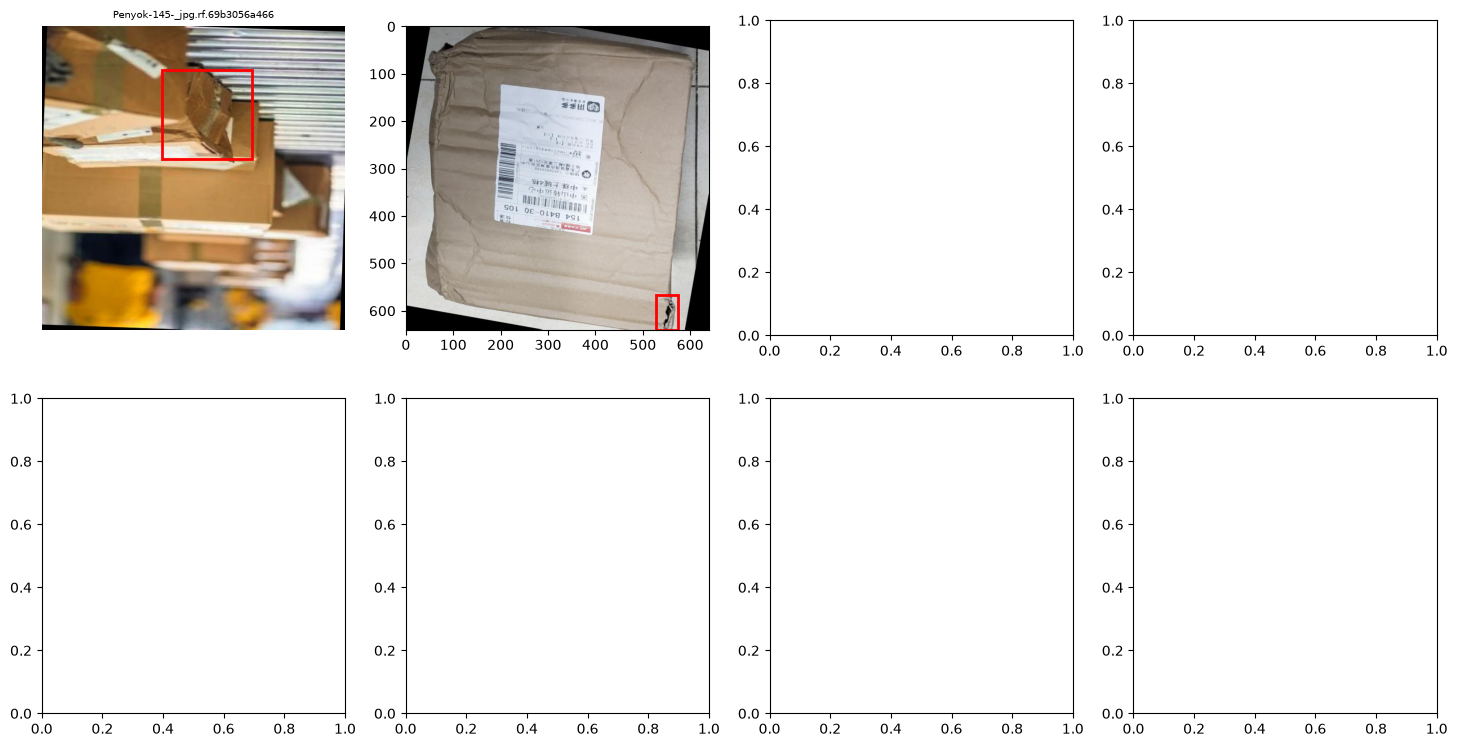

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    img, boxes, h, w = load_image_and_labels(img_path)
    draw_boxes(ax, img, boxes, h, w)
    ax.set_title(img_path.stem[:30], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# التحقق من GPU
import torch
print(f'✅ PyTorch version: {torch.__version__}')
print(f'✅ CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️ No GPU found — go to Runtime → Change runtime type → GPU')

✅ PyTorch version: 2.11.0+cu128
✅ CUDA available: True
✅ GPU: NVIDIA RTX 2000 Ada Generation


In [13]:
# # ── Visualise random training samples with ground-truth boxes ───────────────
# def load_image_and_labels(img_path: Path):
#     """
#     Load an image and its corresponding YOLO-format label file.
#     Returns the BGR image and a list of (class_id, cx, cy, w, h) tuples.
#     """
#     img   = cv2.imread(str(img_path))
#     img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     h, w  = img.shape[:2]

#     lbl_path = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
#     boxes = []
#     if lbl_path.exists():
#         with open(lbl_path) as f:
#             for line in f:
#                 parts = list(map(float, line.split()))
#                 boxes.append(parts)
#     return img, boxes, h, w

# def draw_boxes(ax, img, boxes, h, w):
#     """Draw YOLO bounding boxes on a matplotlib Axes."""
#     ax.imshow(img)
#     palette = plt.cm.Set1.colors
#     for box in boxes:
#         cls_id, cx, cy, bw, bh = int(box[0]), *box[1:]
#         x1 = (cx - bw / 2) * w
#         y1 = (cy - bh / 2) * h
#         rect = patches.Rectangle(
#             (x1, y1), bw * w, bh * h,
#             linewidth=2, edgecolor=palette[cls_id % len(palette)],
#             facecolor='none'
#         )
#         ax.add_patch(rect)
#         ax.text(x1, y1 - 4, CLASS_NAMES[cls_id],
#                 color='white', fontsize=8,
#                 bbox=dict(facecolor=palette[cls_id % len(palette)], alpha=0.7, pad=1))
#     ax.axis('off')

# # Pick 8 random training images
# train_imgs = list((DATASET_DIR / 'train' / 'images').glob('*.jpg')) + \
#              list((DATASET_DIR / 'train' / 'images').glob('*.png'))
# samples    = random.sample(train_imgs, min(8, len(train_imgs)))

# fig, axes = plt.subplots(2, 4, figsize=(18, 9))
# for ax, img_path in zip(axes.flat, samples):
#     img, boxes, h, w = load_image_and_labels(img_path)
#     draw_boxes(ax, img, boxes, h, w)
#     ax.set_title(img_path.stem[:30], fontsize=7)

# plt.suptitle('🖼️  Random Training Samples (Ground-Truth Boxes)', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved → sample_images.png")

Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.


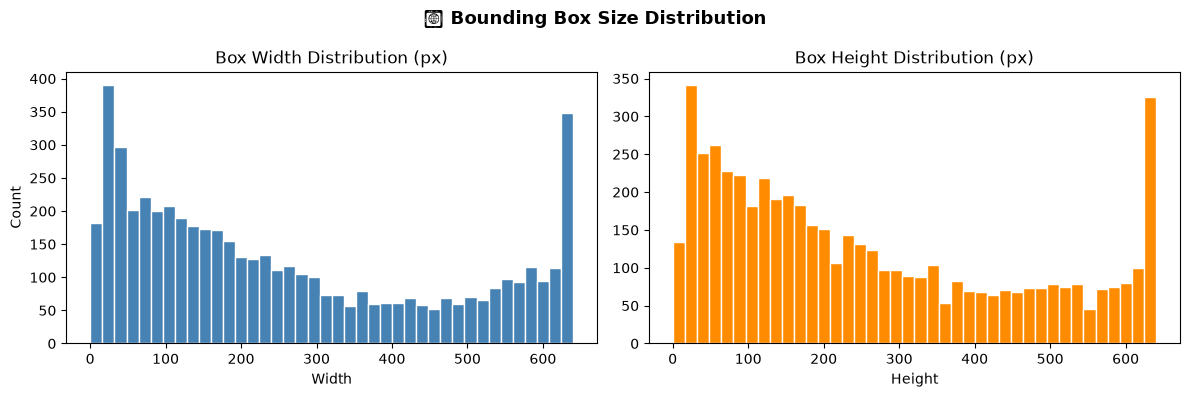

  Median box width  : 198.8 px
  Median box height : 198.8 px
  Min box width     : 0.2 px
  Min box height    : 0.5 px


In [14]:
# ── Bounding box size distribution ─────────────────────────────────────────
# Understanding box sizes helps choose the right input resolution:
#   • Many tiny boxes  → use larger imgsz (1280) or multi-scale training
#   • Large/medium boxes → 640 is usually sufficient

widths, heights = [], []
for img_path in train_imgs:
    img      = cv2.imread(str(img_path))
    h, w     = img.shape[:2]
    lbl_path = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = list(map(float, line.split()))
                widths.append(parts[3] * w)
                heights.append(parts[4] * h)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths,  bins=40, color='steelblue', edgecolor='white')
ax1.set_title('Box Width Distribution (px)');  ax1.set_xlabel('Width');  ax1.set_ylabel('Count')
ax2.hist(heights, bins=40, color='darkorange', edgecolor='white')
ax2.set_title('Box Height Distribution (px)'); ax2.set_xlabel('Height')
plt.suptitle('📐 Bounding Box Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('box_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Median box width  : {np.median(widths):.1f} px")
print(f"  Median box height : {np.median(heights):.1f} px")
print(f"  Min box width     : {np.min(widths):.1f} px")
print(f"  Min box height    : {np.min(heights):.1f} px")

## 4️⃣  Dataset YAML Review & Custom Augmentation Config

> **Strategy for high accuracy**  
> - Use **YOLOv8x** (eXtra-large) — highest capacity, best mAP  
> - `imgsz = 1280` — captures small defects missed at 640  
> - Heavy augmentation: mosaic, mixup, copy-paste, random perspective  
> - Cosine LR schedule + warmup  
> - Long training (200+ epochs) + early stopping  
> - Test-Time Augmentation (TTA) at inference

In [15]:
# ── Print and optionally patch the data.yaml ───────────────────────────────
# Make sure the paths inside data.yaml are absolute so ultralytics can
# find them regardless of the working directory.

with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

# Fix relative paths → absolute
for key in ('train', 'val', 'test'):
    if key in config:
        p = Path(config[key])
        if not p.is_absolute():
            config[key] = str(DATASET_DIR / p)

with open(DATA_YAML, 'w') as f:
    yaml.dump(config, f)

print("✅  data.yaml (absolute paths):")
print(yaml.dump(config, default_flow_style=False))

✅  data.yaml (absolute paths):
names:
- no defect
- torn
- wrinkle
nc: 3
roboflow:
  license: CC BY 4.0
  project: cardboard-box-defect-qkrrj-jzm1k
  url: https://universe.roboflow.com/psm-cqw6v/cardboard-box-defect-qkrrj-jzm1k/dataset/2
  version: 2
  workspace: psm-cqw6v
test: Cardboard-Box-Defect-2\test\images
train: Cardboard-Box-Defect-2\train\images
val: Cardboard-Box-Defect-2\valid\images



## 5️⃣  Model Training — High-Accuracy Settings

In [20]:
# ── Training hyperparameter overview ────────────────────────────────────────
#
# MODEL    : yolov8x   → the eXtra-large variant; ~68M params, highest mAP
#            (swap to yolov8l if VRAM < 16 GB, or yolov8m if < 8 GB)
#
# imgsz    : 1280      → large resolution = better detection of tiny defects
#            (reduce to 640 if you run out of VRAM)
#
# epochs   : 200       → enough for convergence with early stopping
# patience : 30        → stop if val/mAP50 does not improve for 30 epochs
#
# batch    : 8         → per-GPU batch (increase if VRAM allows, e.g. 16)
#
# optimizer: AdamW     → adaptive learning rate, better generalisation
# lr0      : 0.001     → initial learning rate (cosine decay to lrf)
# lrf      : 0.01      → final LR = lr0 * lrf → 0.00001
# warmup_epochs: 5     → gradual LR ramp-up to avoid early instability
#
# Augmentation flags (all enabled for maximum robustness):
#   mosaic    : 1.0    → combine 4 images in one tile (default = 1.0)
#   mixup     : 0.15   → blend two images + labels (slight)
#   copy_paste: 0.1    → copy objects between images
#   degrees   : 10.0   → random rotation ± 10°
#   flipud    : 0.5    → vertical flip (common for top-down defect shots)
#   fliplr    : 0.5    → horizontal flip
#   hsv_h/s/v        → colour jitter for lighting invariance
#   perspective: 0.001 → slight projective distortion
#   scale    : 0.5     → random scale ± 50 %
#
# save_period: 10      → checkpoint every 10 epochs
# val        : True    → run validation after each epoch
# plots      : True    → save training curves automatically

print("Hyperparameter overview printed above — proceed to training cell.")

Hyperparameter overview printed above — proceed to training cell.


In [16]:
import os
from pathlib import Path

# Delete the corrupted file
corrupted = Path.home() / "AppData/Local/Ultralytics/Assets/yolov8m.pt"  # Windows default cache
if corrupted.exists():
    os.remove(corrupted)
    print(f"🗑️  Deleted corrupted file: {corrupted}")

# Also check current working directory
local = Path("yolov8m.pt")
if local.exists():
    os.remove(local)
    print(f"🗑️  Deleted corrupted file: {local}")

🗑️  Deleted corrupted file: yolov8m.pt


In [17]:
from ultralytics import YOLO
from ultralytics.utils.downloads import attempt_download_asset

# Force fresh download
attempt_download_asset("yolov8m.pt")

# Now load
model = YOLO("yolov8m.pt")
print(f"Parameters : {sum(p.numel() for p in model.model.parameters()):,}")

Parameters : 25,902,640


In [18]:
# # ── Load the pretrained YOLOv8m backbone ────────────────────────────────────
# # Pretrained on COCO (80 classes). We fine-tune the head on our defect classes.
# # Transfer learning drastically reduces the epochs needed for convergence.
# # Using YOLOv8m (medium) instead of x for faster training.
# 
model = YOLO('yolov8m.pt')   # downloads ~49 MB on first run (much faster than yolov8x)
print(f"Model loaded  : {model.info()}")
print(f"Parameters    : {sum(p.numel() for p in model.model.parameters()):,}")

YOLOv8m summary: 169 layers, 25,902,640 parameters, 0 gradients, 79.3 GFLOPs
Model loaded  : (169, 25902640, 0, 79.3204224)
Parameters    : 25,902,640


In [19]:
import yaml
from pathlib import Path

yaml_path = "Cardboard-Box-Defect-2/data.yaml"
base      = Path("Cardboard-Box-Defect-2")

with open(yaml_path) as f:
    cfg = yaml.safe_load(f)

cfg["train"] = str(base / "train/images")
cfg["val"]   = str(base / "valid/images")
cfg["test"]  = str(base / "test/images")

with open(yaml_path, "w") as f:
    yaml.dump(cfg, f)

print("✅ data.yaml patched")

✅ data.yaml patched


In [21]:
# ── TRAIN ──────────────────────────────────────────────────────────────────
# All outputs (weights, logs, plots) are saved to:
#   runs/detect/cardboard_defect_yolov8m/
# Using YOLOv8m with 640 resolution for ~4-5x faster training than yolov8x@1280

results = model.train(
    # ── Data ──────────────────────────────────────────────────────────
    data        = str(DATA_YAML),
    imgsz       = 640,         # reduced from 1280 for speed (faster 4-5x)

    # ── Training schedule ─────────────────────────────────────────────
    epochs      = 100,         # reduced from 200 (with early stopping at 30)
    patience    = 10,          # EarlyStopping: halt if no mAP improvement
    batch       = 8,          # increased from 8 (medium model is smaller)
    workers     = 4,           # data-loading workers

    # ── Optimiser & LR ────────────────────────────────────────────────
    optimizer   = 'AdamW',
    lr0         = 0.001,       # starting learning rate
    lrf         = 0.01,        # final LR fraction (cosine schedule)
    momentum    = 0.937,
    weight_decay= 0.0005,
    warmup_epochs     = 5,
    warmup_momentum   = 0.8,
    warmup_bias_lr    = 0.1,

    # ── Augmentation ──────────────────────────────────────────────────
    mosaic      = 1.0,         # mosaic augmentation probability
    mixup       = 0.15,        # MixUp probability
    copy_paste  = 0.1,         # copy-paste augmentation
    degrees     = 10.0,        # rotation range (±10°)
    translate   = 0.1,         # image translation (±10 %)
    scale       = 0.5,         # scale jitter (±50 %)
    shear       = 2.0,         # shear (±2°)
    perspective = 0.001,       # perspective distortion
    flipud      = 0.5,         # vertical flip probability
    fliplr      = 0.5,         # horizontal flip probability
    hsv_h       = 0.015,       # hue jitter
    hsv_s       = 0.7,         # saturation jitter
    hsv_v       = 0.4,         # brightness jitter

    # ── Loss weights ──────────────────────────────────────────────────
    box         = 7.5,         # box regression loss weight
    cls         = 0.5,         # classification loss weight
    dfl         = 1.5,         # distribution focal loss weight

    # ── Misc ──────────────────────────────────────────────────────────
    project     = 'runs/detect',
    name        = 'cardboard_defect_yolov8m',
    exist_ok    = True,
    device      = 0 if device == 'cuda' else 'cpu',
    seed        = SEED,
    save_period = 10,          # save checkpoint every 10 epochs
    val         = True,        # validate after each epoch
    plots       = True,        # auto-generate training curve plots
    verbose     = True,
)

print("\n✅  Training complete!")
print(f"   Best weights → {results.save_dir}/weights/best.pt")

Ultralytics 8.4.67  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Cardboard-Box-Defect-2\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cardboard_defect_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimiz

## 6️⃣  Training Curves & Metrics

In [ ]:
# ── Display auto-generated training plots ──────────────────────────────────
# Ultralytics saves these PNGs to the run directory automatically:
#   results.png   → loss, precision, recall, mAP over epochs
#   labels.jpg    → label distribution heatmap

RUN_DIR = Path(results.save_dir)

for plot_name in ['results.png', 'labels.jpg', 'labels_correlogram.jpg']:
    plot_path = RUN_DIR / plot_name
    if plot_path.exists():
        print(f"\n📈  {plot_name}")
        display(Image(filename=str(plot_path), width=900))

In [ ]:
# ── Parse results.csv and plot custom curves ───────────────────────────────
import pandas as pd

csv_path = RUN_DIR / 'results.csv'
if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()  # remove leading/trailing spaces

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    metrics_to_plot = [
        ('train/box_loss', 'Box Loss (train)', 'tab:blue'),
        ('train/cls_loss', 'Class Loss (train)', 'tab:orange'),
        ('val/box_loss',   'Box Loss (val)',   'tab:cyan'),
        ('metrics/mAP50(B)',   'mAP@50',         'tab:green'),
        ('metrics/mAP50-95(B)','mAP@50-95',       'tab:red'),
        ('metrics/precision(B)',  'Precision',  'tab:purple'),
    ]

    for ax, (col, title, color) in zip(axes.flat, metrics_to_plot):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3)
            best_val = df[col].max() if 'mAP' in col or 'prec' in col else df[col].min()
            ax.axhline(best_val, color='black', linestyle='--', alpha=0.5,
                       label=f'Best: {best_val:.4f}')
            ax.legend(fontsize=8)

    plt.suptitle('📊  YOLOv8x Training Curves — Cardboard Defect', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Print best metrics ──────────────────────────────────────────────
    map50    = df['metrics/mAP50(B)'].max()   if 'metrics/mAP50(B)'    in df.columns else 'N/A'
    map5095  = df['metrics/mAP50-95(B)'].max() if 'metrics/mAP50-95(B)' in df.columns else 'N/A'
    best_epoch = df['metrics/mAP50(B)'].idxmax() if 'metrics/mAP50(B)' in df.columns else 'N/A'

    print(f"\n🏆  Best Results:")
    print(f"   mAP@50     : {map50:.4f}" if isinstance(map50, float) else f"   mAP@50     : {map50}")
    print(f"   mAP@50-95  : {map5095:.4f}" if isinstance(map5095, float) else f"   mAP@50-95  : {map5095}")
    print(f"   Best epoch : {best_epoch}")

## 7️⃣  Validation — Full mAP Evaluation

In [ ]:
# ── Load the best checkpoint and run validation ────────────────────────────
# We use half-precision (fp16) for speed; remove half=True on CPU.

best_weights = RUN_DIR / 'weights' / 'best.pt'
model_best   = YOLO(str(best_weights))

val_metrics = model_best.val(
    data    = str(DATA_YAML),
    imgsz   = 1280,
    batch   = 8,
    split   = 'test',           # evaluate on the held-out test set
    conf    = 0.001,            # low conf during eval to compute full PR curve
    iou     = 0.6,              # NMS IoU threshold
    half    = (device == 'cuda'),
    device  = 0 if device == 'cuda' else 'cpu',
    plots   = True,             # saves confusion matrix & PR curve
    save_json = True,           # saves predictions in COCO JSON format
    verbose = True,
)

print("\n✅  Validation complete")
print(f"   mAP@50    : {val_metrics.box.map50:.4f}")
print(f"   mAP@50-95 : {val_metrics.box.map:.4f}")
print(f"   Precision : {val_metrics.box.mp:.4f}")
print(f"   Recall    : {val_metrics.box.mr:.4f}")

In [ ]:
# ── Per-class AP ───────────────────────────────────────────────────────────
# ap_class_index : indices of classes that were detected at least once
# box.ap50       : AP at IoU=0.50 per class

ap50_per_class = val_metrics.box.ap50          # numpy array
class_indices  = val_metrics.ap_class_index    # which classes

fig, ax = plt.subplots(figsize=(10, 4))
names   = [CLASS_NAMES[i] for i in class_indices]
colors  = sns.color_palette('Set2', len(names))
bars    = ax.bar(names, ap50_per_class, color=colors)
ax.bar_label(bars, fmt='%.3f', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('AP@50')
ax.set_title('Per-Class Average Precision @ IoU=0.50', fontsize=13, fontweight='bold')
ax.axhline(ap50_per_class.mean(), color='black', linestyle='--',
           label=f'mAP@50 = {ap50_per_class.mean():.3f}')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('per_class_ap50.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Display confusion matrix and PR curve (auto-saved by ultralytics) ───────
val_run_dir = Path(val_metrics.save_dir)

for fname in ['confusion_matrix_normalized.png', 'PR_curve.png', 'F1_curve.png']:
    fp = val_run_dir / fname
    if fp.exists():
        print(f"\n📊  {fname}")
        display(Image(filename=str(fp), width=700))

## 8️⃣  Inference on Test Images (with TTA)

In [ ]:
# ── Run inference with Test-Time Augmentation (TTA) ────────────────────────
# TTA runs the model over several flipped/scaled versions of each image
# and merges the predictions → consistently higher mAP (+1-2 %) at inference.
#
# conf  = 0.25  → only show boxes with ≥ 25 % confidence
# iou   = 0.45  → NMS: suppress overlapping boxes with IoU > 0.45
# augment = True → enable TTA

test_img_dir = DATASET_DIR / 'test' / 'images'
test_images  = list(test_img_dir.glob('*.jpg')) + list(test_img_dir.glob('*.png'))

# Run on all test images; results saved to runs/detect/infer_tta/
predictions = model_best.predict(
    source  = str(test_img_dir),
    imgsz   = 1280,
    conf    = 0.25,
    iou     = 0.45,
    augment = True,            # TTA
    save    = True,
    save_txt= True,
    save_conf=True,
    project = 'runs/detect',
    name    = 'infer_tta',
    exist_ok= True,
    device  = 0 if device == 'cuda' else 'cpu',
)

print(f"\n✅  Inference done on {len(predictions)} images")
print(f"   Saved to → runs/detect/infer_tta/")

In [ ]:
# ── Visualise 8 random predictions using supervision ───────────────────────
# supervision provides a clean API for drawing bounding boxes,
# labels, and confidence scores on images.

annotator = sv.BoxAnnotator(thickness=2)
label_ann  = sv.LabelAnnotator(text_scale=0.5, text_thickness=1)

sample_preds = random.sample(predictions, min(8, len(predictions)))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, result in zip(axes.flat, sample_preds):
    img_bgr = cv2.imread(result.path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Convert ultralytics result → supervision Detections
    det = sv.Detections.from_ultralytics(result)

    # Build label strings: "class_name conf%"
    labels = [
        f"{CLASS_NAMES[c]} {conf:.0%}"
        for c, conf in zip(det.class_id, det.confidence)
    ]

    annotated = annotator.annotate(scene=img_rgb.copy(), detections=det)
    annotated = label_ann.annotate(scene=annotated, detections=det, labels=labels)

    ax.imshow(annotated)
    ax.axis('off')
    ax.set_title(f"{Path(result.path).stem[:30]}  [{len(det)} box(es)]", fontsize=7)

plt.suptitle('🔍  YOLOv8x Predictions on Test Set (TTA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → test_predictions.png")

In [ ]:
# ── Detection statistics on the test set ───────────────────────────────────
all_detected_classes = []
all_confidences      = []
imgs_with_detections = 0

for result in predictions:
    if len(result.boxes) > 0:
        imgs_with_detections += 1
        for box in result.boxes:
            all_detected_classes.append(CLASS_NAMES[int(box.cls)])
            all_confidences.append(float(box.conf))

detect_dist = Counter(all_detected_classes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Detection counts per class
ax1.bar(detect_dist.keys(), detect_dist.values(),
        color=sns.color_palette('Set2', len(detect_dist)))
ax1.set_title('Detected Instances per Class', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class'); ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=30)

# Confidence score distribution
ax2.hist(all_confidences, bins=30, color='steelblue', edgecolor='white')
ax2.axvline(np.mean(all_confidences), color='red', linestyle='--',
            label=f'Mean = {np.mean(all_confidences):.2f}')
ax2.set_title('Confidence Score Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Confidence'); ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('inference_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊  Inference Summary")
print(f"   Total test images        : {len(predictions)}")
print(f"   Images with detections   : {imgs_with_detections}")
print(f"   Total detections         : {len(all_confidences)}")
print(f"   Mean confidence          : {np.mean(all_confidences):.3f}")
print(f"   Detections per class     : {dict(detect_dist)}")

## 9️⃣  Confusion Matrix & PR Curve (custom)

In [ ]:
# ── Display the normalised confusion matrix generated during validation ─────
# The normalised matrix shows the fraction of ground-truth instances per class
# that were predicted correctly or confused with another class.
# Ideal: diagonal ≈ 1.0, off-diagonal ≈ 0.0

cm_path = val_run_dir / 'confusion_matrix_normalized.png'
if cm_path.exists():
    display(Image(filename=str(cm_path), width=700))
else:
    print("Confusion matrix not yet generated — run Section 7 first.")

In [ ]:
# ── Speed benchmark ────────────────────────────────────────────────────────
# Measure end-to-end inference latency (ms) on a single image.
# Useful for deciding whether to deploy the x-model or switch to a lighter one.

import time

sample_img = test_images[0]
N_RUNS     = 20

# Warm-up
_ = model_best.predict(str(sample_img), imgsz=1280, verbose=False,
                        device=0 if device == 'cuda' else 'cpu')

# Timed runs
times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    _  = model_best.predict(str(sample_img), imgsz=1280, verbose=False,
                             device=0 if device == 'cuda' else 'cpu')
    times.append((time.perf_counter() - t0) * 1000)

print(f"\n⚡  Inference Speed ({N_RUNS} runs, imgsz=1280)")
print(f"   Mean     : {np.mean(times):.1f} ms")
print(f"   Std      : {np.std(times):.1f} ms")
print(f"   Min      : {np.min(times):.1f} ms")
print(f"   Max      : {np.max(times):.1f} ms")
print(f"   FPS est. : {1000 / np.mean(times):.1f}")

## 🔟  Model Export

In [ ]:
# ── Export to ONNX (universal deployment format) ───────────────────────────
# ONNX is supported by OpenVINO, TensorRT, ONNX Runtime, and many edge devices.
# dynamic=True allows variable batch sizes at inference time.

onnx_path = model_best.export(
    format  = 'onnx',
    imgsz   = 1280,
    dynamic = True,
    simplify= True,    # ONNX simplifier removes redundant ops
    half    = (device == 'cuda'),
)
print(f"\n✅  ONNX model → {onnx_path}")

In [ ]:
# ── Export to TorchScript (for C++ and mobile deployment) ──────────────────
ts_path = model_best.export(format='torchscript', imgsz=1280, optimize=True)
print(f"✅  TorchScript model → {ts_path}")

## 🏁  Summary

| Item | Value |
|------|-------|
| Model | YOLOv8x |
| Input resolution | 1280 × 1280 |
| Epochs (max) | 200 (early-stop @30) |
| Augmentations | Mosaic, MixUp, CopyPaste, Flip, Perspective |
| Optimiser | AdamW + cosine LR |
| Best weights | `runs/detect/cardboard_defect_yolov8x/weights/best.pt` |
| Exports | ONNX (dynamic), TorchScript |

### 🔧 Tips to Push Accuracy Further

1. **Pseudo-labelling** — run the best model on unlabelled images, filter high-confidence predictions, and add them to training.  
2. **Multi-scale training** — repeat training at 640 and 960 too, then ensemble.  
3. **WBF ensembling** — combine predictions from YOLOv8x + YOLOv8l with Weighted Box Fusion.  
4. **More data** — Roboflow Universe has similar cardboard datasets you can merge.  
5. **Hyperparameter search** — use `ultralytics.utils.tuner` for automated HP tuning.